In [1]:
import sys
import cospar as cs
import scanpy as sc
import numpy as np
from scipy.sparse import csr_matrix
'''
    For better visualization you can change the matplotlib settings to our defaults with:
'''
cs.settings.set_figure_params()

Time points with clonal info: []
Step I: Generate pseudo clones where each cell has a unique barcode-----
Step II: Perform joint optimization-----
--------Infer transition map between initial time points and the later time one-------
--------Current initial time point: 1--------
Step 0: Pre-processing and sub-sampling cells-------
--> Compute similarity matrix: computing new; beta=0.1


f:\Software\ANACONDA\envs\test_cospar\lib\site-packages\cospar\tmap\map_reconstruction.py:572: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["data_des"] = [data_des_orig, data_des]
f:\Software\ANACONDA\envs\test_cospar\lib\site-packages\cospar\tmap\map_reconstruction.py:851: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["data_des"] = [data_des_orig, data_des]


Smooth round: 1
--> Time elapsed: 0.14765095710754395
Smooth round: 2
--> Time elapsed: 0.15520024299621582
Smooth round: 3
--> Time elapsed: 0.9401793479919434
--> Orignal sparsity=0.10232912146235405, Thresholding
--> Final sparsity=0.06793354734675802
similarity matrix truncated (Smooth round=3):  1.583711862564087
Smooth round: 4
--> Time elapsed: 1.8985564708709717
--> Orignal sparsity=0.17291129058699273, Thresholding
--> Final sparsity=0.1089605908009897
similarity matrix truncated (Smooth round=4):  1.534224033355713
Smooth round: 5
--> Time elapsed: 2.5579819679260254
--> Orignal sparsity=0.21689565708176445, Thresholding
--> Final sparsity=0.14518693413446934
similarity matrix truncated (Smooth round=5):  1.6719980239868164
--> Save the matrix at every 5 rounds
Smooth round: 6
--> Time elapsed: 3.1559975147247314
--> Orignal sparsity=0.25099052841137404, Thresholding
--> Final sparsity=0.17637657236420143
similarity matrix truncated (Smooth round=6):  1.6267304420471191
Smoot

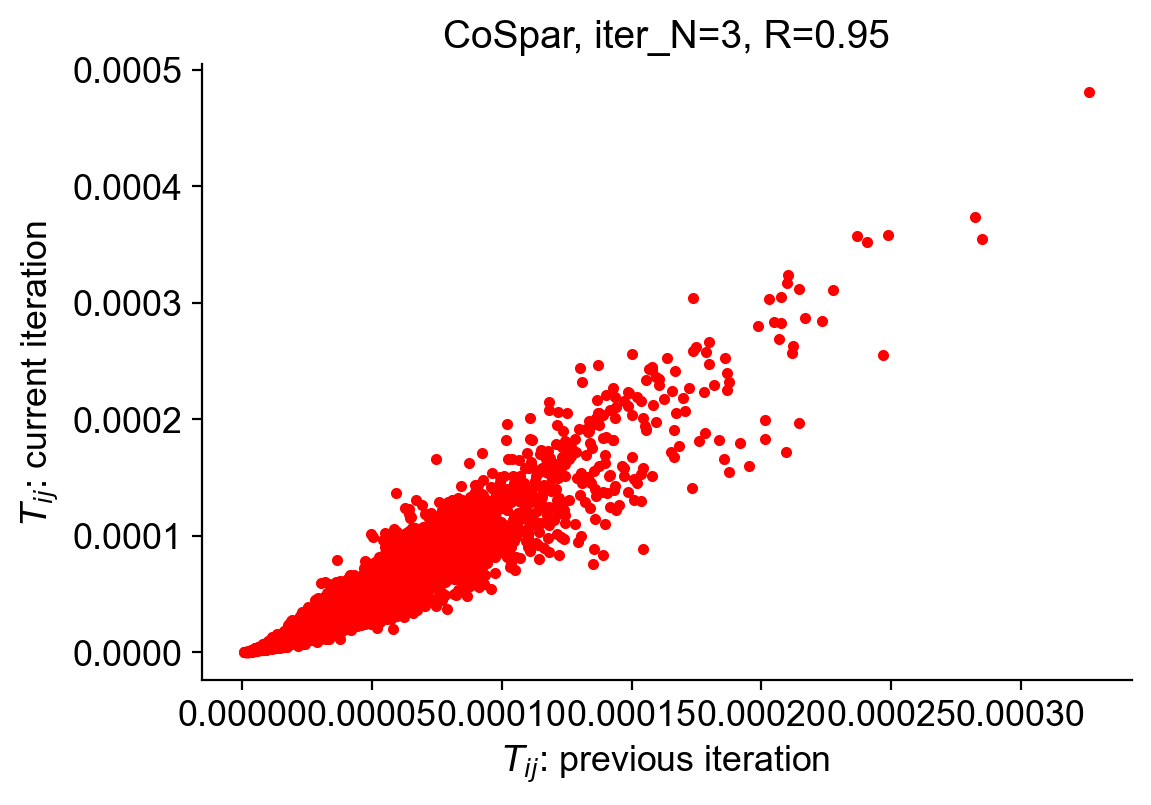

--> No need for Final Smooth (i.e., clonally-labeled states are the final state space for Tmap)
--> ----Intraclone transition map----
--> Clone normalization
--> Relative time point pair index: 0
--> Clone id: 0
--> Clone id: 1000
--> Clone id: 2000
--> Clone id: 3000
--> Clone id: 4000
--> Clone id: 5000
--> Clone id: 6000
--> Clone id: 7000
--> Clone id: 8000
--> Clone id: 9000
--> Clone id: 10000
--> Clone id: 11000


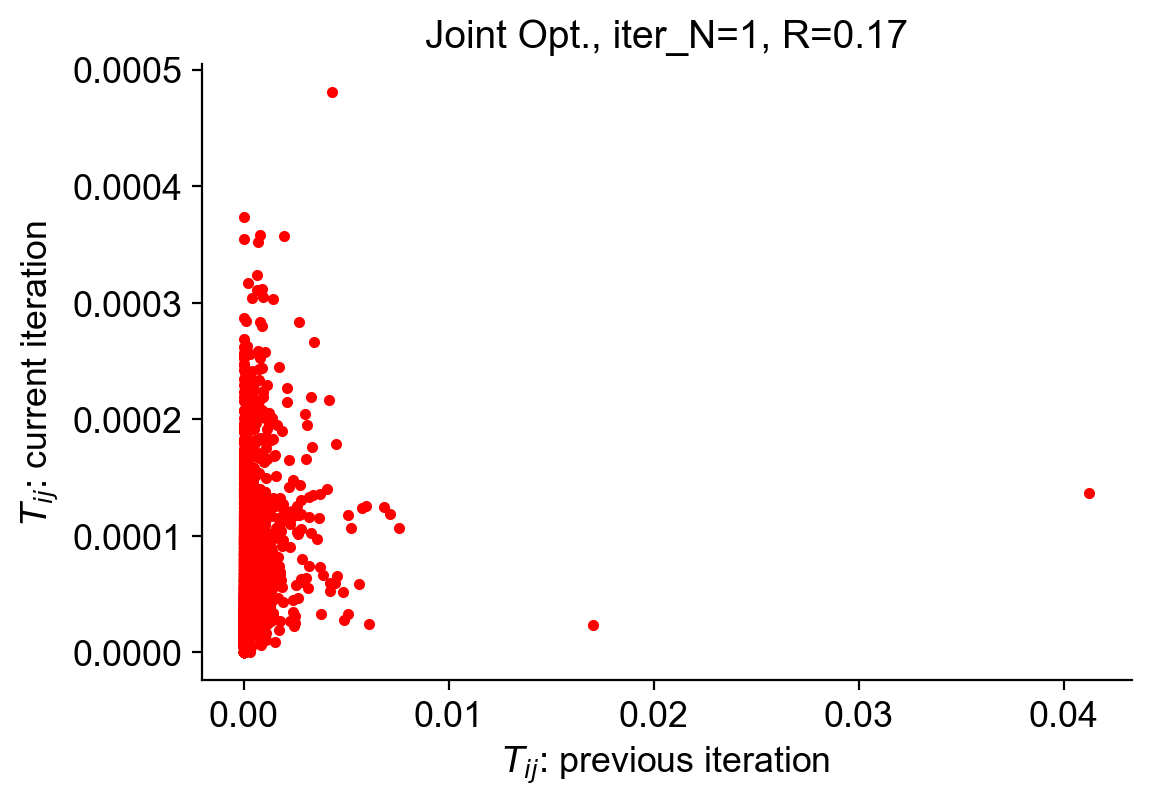

Finishing Joint Optimization, used time 79.93394494056702
-----------Total used time: 425.0914454460144 s ------------
Results saved at adata.obs['fate_map_transition_map_Neutrophil']
Results saved at adata.obs['fate_map_transition_map_Monocyte']
Results saved at adata.obs['fate_bias_transition_map_Neutrophil*Monocyte']


In [31]:
adata = sc.read('D:/scLT/Weinreb/0814/desc6.1/anndata.h5ad')
adata.obs['time_info'] = np.where(
    adata.obs['Cell.type.annotation'] == 'Undifferentiated',
    1,
    2
)
adata.obs['state_info'] = adata.obs['Cell.type.annotation']

adata_orig = cs.pp.initialize_adata_object(adata=adata)

adata_orig.X = csr_matrix(adata_orig.X)
adata_orig.obsm['X_pca'] = adata_orig.obsm['X_emb']

adata = cs.tmap.infer_Tmap_from_state_info_alone(
    adata_orig,
    initial_time_points=[1],
    later_time_point=2,
    initialize_method="OT",
    OT_cost="GED",
    smooth_array=[20, 15, 10],
    max_iter_N=[1, 3],
    sparsity_threshold=0.2,
    use_full_Smatrix=True,
    compute_new=True
)

cs.tl.fate_bias(
    adata,
    selected_fates=["Neutrophil", "Monocyte"],
    source="transition_map",
    pseudo_count=0,
    sum_fate_prob_thresh=0.1,
)

In [32]:
# extract fate bias and ground truth
adata_obs_subset = adata.obs.loc[:, ['ground_truth', 'fate_bias_transition_map_Neutrophil*Monocyte','Cell.type.annotation']]

# extract undifferentiated cells
adata_obs_subset_undiff = adata_obs_subset[adata_obs_subset['Cell.type.annotation'] == 'Undifferentiated']



In [34]:
adata_obs_subset_undiff.to_csv('D:/scLT/Weinreb/0814/desc6.1/cospar.res.csv')

f:\Software\ANACONDA\envs\test_cospar\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


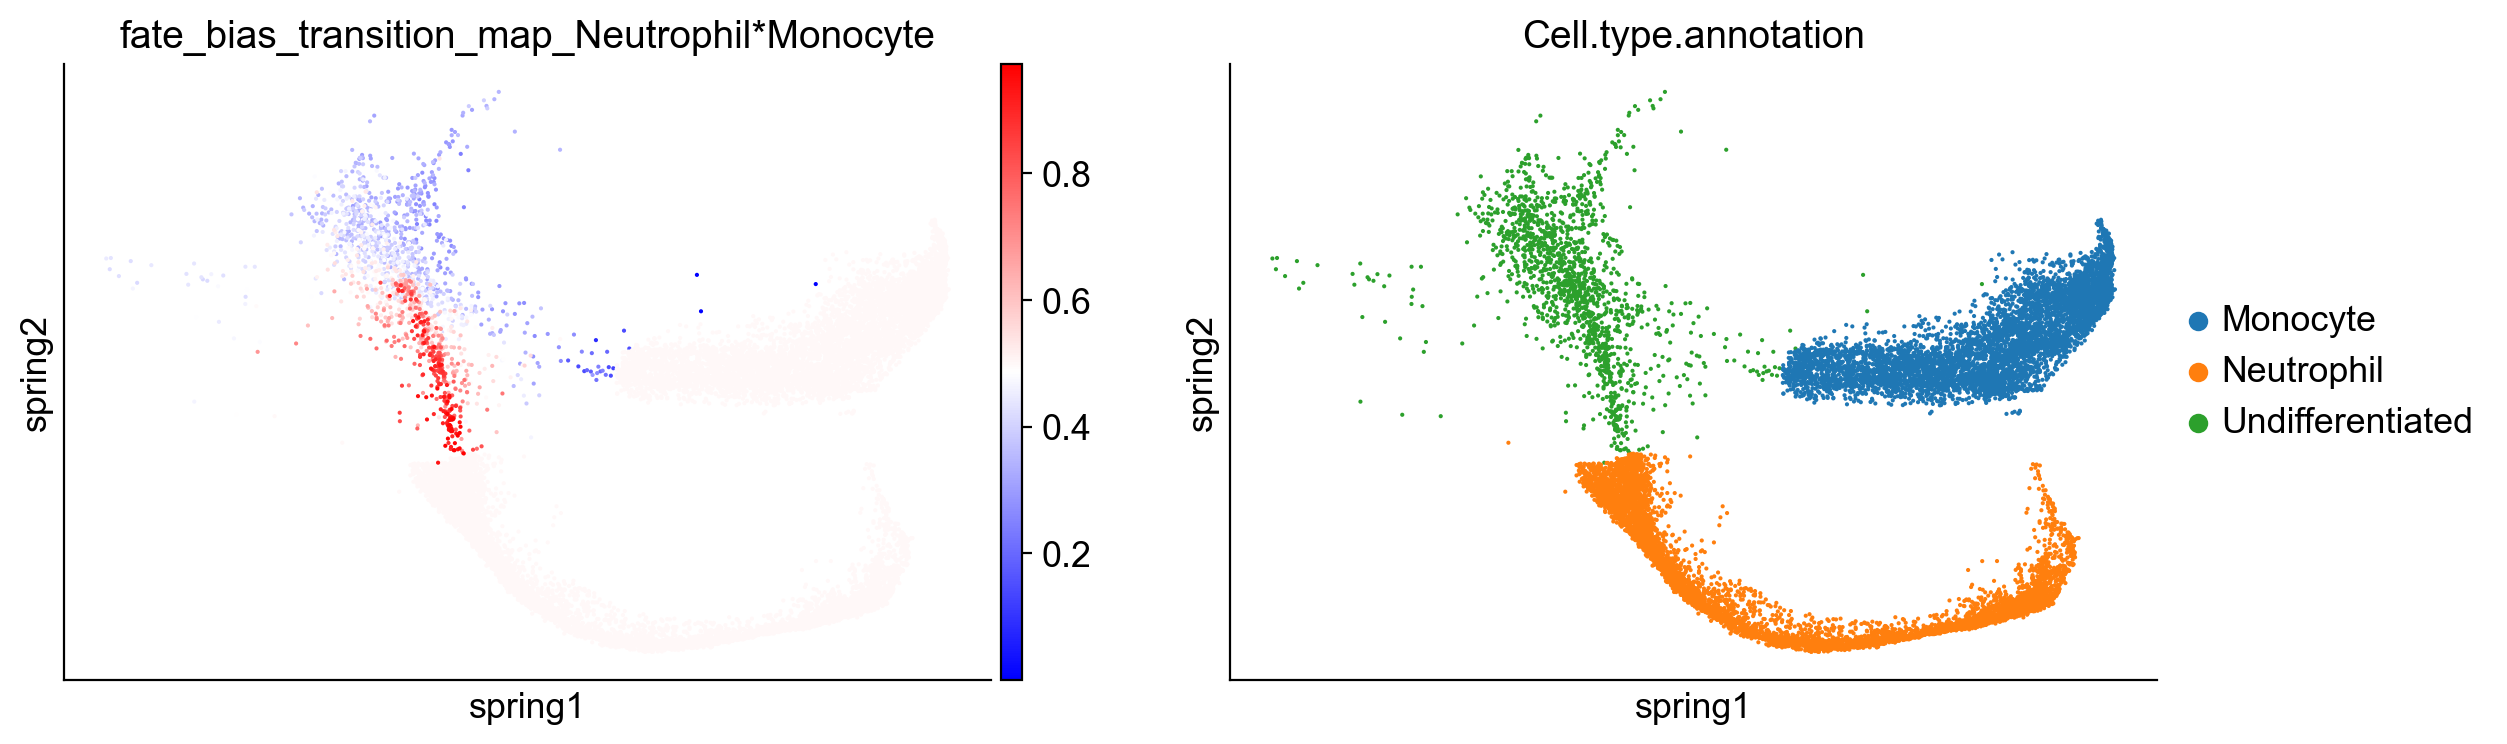

In [33]:
sc.pl.embedding(adata, basis='spring', color=['fate_bias_transition_map_Neutrophil*Monocyte', 'Cell.type.annotation'],cmap='bwr')